## Net generators

## Tipus de xarxes

### No geomètriques

- Erdos-Ranyi (no es scale-free, clustering baix)
- Barabasi-Albert (scale-free, clustering baix)
- Configuracional (clustering = 0)

### Geomètriques

- $\mathbb{S}^1\mathbb{H}^2$


## Equivalència de paràmetres

| Característica                                  | ER                      | BA                                   | Configuracional                                   | S1 / H2                 |
| ----------------------------------------------- | ----------------------- | ------------------------------------ | ------------------------------------------------- | ----------------------- |
| $N$                                             | $N$                     | $N$                                  | $N$                                               | $N$                     |
| Grau mig $\langle k \rangle$                    | $p=\frac{⟨k⟩}{N−1}$     | $m=\frac{⟨k⟩}{2}$​ (ha de ser enter) | En funció de la sequencia o distribució de graus. | $\langle k \rangle$     |
| Exponent de la distribució $\gamma$ (si aplica) | -                       | Fixat, $\gamma = 3$                  | Escollir $P(k) = k^{-\gamma}$                     | $\gamma$                |
| Clustering $C$                                  | Molt baix, no ajustable | Molt baix, no ajustable              | 0, no ajustable                                   | En funció de la $\beta$ |


In [3]:
g = 2.1
n = 1000
b = 2.1
k = 20
m = int(k/2)
p = k/(n-1)
seed = 12345


working_folder = f'./generated-nets-2'
s1h2_working_folder = f'{working_folder}/s1h2-s={seed}'
er_working_folder = f'{working_folder}/er-s={seed}'
ba_working_folder = f'{working_folder}/ba-s={seed}'
conf_working_folder = f'{working_folder}/conf-s={seed}'

er_file = f'{er_working_folder}/er-n={n}-k={k}-s={seed}'
ba_file = f'{ba_working_folder}/ba-n={n}-k={k}-s={seed}'
conf_file = f'{conf_working_folder}/conf-n={n}-k={k}-g={g}-s={seed}'
s1h2_file = f'{s1h2_working_folder}/s1h2-n={n}-k={k}-g={g}-b={b}-s={seed}'

er_edges_file = f'{er_file}.edge'
ba_edges_file = f'{ba_file}.edge'
conf_edges_file = f'{conf_file}.edge'
s1h2_edges_file = f'{s1h2_file}.edge'


er_coords_file = f'{er_file}.inf_coord'
ba_coords_file = f'{ba_file}.inf_coord'
conf_coords_file = f'{conf_file}.inf_coord'
s1h2_coords_file = f'{s1h2_file}.gen_coord'


In [ ]:
import re
import networkx as nx
from pathlib import Path
def generate_powerlaw_sequence_with_avg_k(n, gamma, target_k, k_max=100, tolerance=0.1, seed=12345):
    """
    Genera una secuencia de grados con γ fijo que se aproxime a <k> objetivo.
    """
    import numpy as np
    # Buscar k_min que dé el <k> deseado
    k_min = 1
    best_seq = None
    best_avg = 0
    rng = np.random.RandomState(seed)
    for k_min_candidate in range(1, 20):
        # Generar grados con este k_min
        degrees = []
        while len(degrees) < n:
            # Muestreo por transformada inversa
            r = rng.random()
            k = k_min_candidate * (1 - r) ** (-1/(gamma-1))
            if k <= k_max:
                degrees.append(int(np.floor(k)))
        
        # Ajustar para que la suma sea par (requisito del modelo de configuración)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1
        
        current_avg = np.mean(degrees)
        
        if abs(current_avg - target_k) < abs(best_avg - target_k):
            best_avg = current_avg
            best_seq = degrees
        
        if abs(current_avg - target_k) < tolerance:
            return degrees
    
    return best_seq

Gba = nx.barabasi_albert_graph(n, m, seed=seed)
sequence = generate_powerlaw_sequence_with_avg_k(n, gamma=g, target_k=k, seed=seed, tolerance=0.001)
Gconf = nx.configuration_model(sequence)
Ger = nx.erdos_renyi_graph(n, p, seed=seed)

! mkdir -p {s1h2_working_folder}
! mkdir -p {er_working_folder}
! mkdir -p {ba_working_folder}
! mkdir -p {conf_working_folder}

nx.write_edgelist(Gba, ba_edges_file, data=False)
nx.write_edgelist(Ger, er_edges_file, data=False)
nx.write_edgelist(Gconf, conf_edges_file, data=False)
! ./tools/genSD -d 1 -n {n} -g {g} -k {k} -b {b} -s {seed} -t 4 -v -o {s1h2_file} 
# remove v from node name
t = Path(s1h2_edges_file).read_text()
t = re.sub(r'v(\d)', r'\1', t)
Path(s1h2_edges_file).write_text(t)

t = Path(s1h2_coords_file).read_text()
t = re.sub(r'v(\d)', r'\1', t)
Path(s1h2_coords_file).write_text(t)

Gs1h2 = nx.read_edgelist(s1h2_edges_file)

OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/./statistics-nets/s1h2-n=1000-k=20-g=2.1-b=2.1-s=12345
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/./statistics-nets/s1h2-n=1000-k=20-g=2.1-b=2.1-s=12345.edge


# Generació

In [ ]:
! ./tools/mercator -o {er_file} -g -s {seed} {er_edges_file}
! ./tools/mercator -o {ba_file} -g -s {seed} {ba_edges_file}
! ./tools/mercator -o {conf_file} -g -s {seed} {conf_edges_file}

In [4]:
import pipeline.data as data

Gba, dfba, paramsba = data.read_hyperbolic_data(ba_coords_file, ba_edges_file)
Ger, dfer, paramser = data.read_hyperbolic_data(er_coords_file, er_edges_file)
Gconf, dfconf, paramsconf = data.read_hyperbolic_data(conf_coords_file, conf_edges_file)
Gs1h2 , dfs1h2, paramss1h2 = data.read_hyperbolic_data(s1h2_coords_file, s1h2_edges_file, True)

## Mapa

In [3]:
import numpy as np
positions = {v: (x, y) for _, (v, x, y) in dfs1h2[['Vertex', 'Disc.X', 'Disc.Y']].iterrows()}
        
kappa_vals = np.log10(dfs1h2['Inf.Kappa'])

len(positions), len(kappa_vals), len(dfs1h2)

(1000, 1000, 1000)

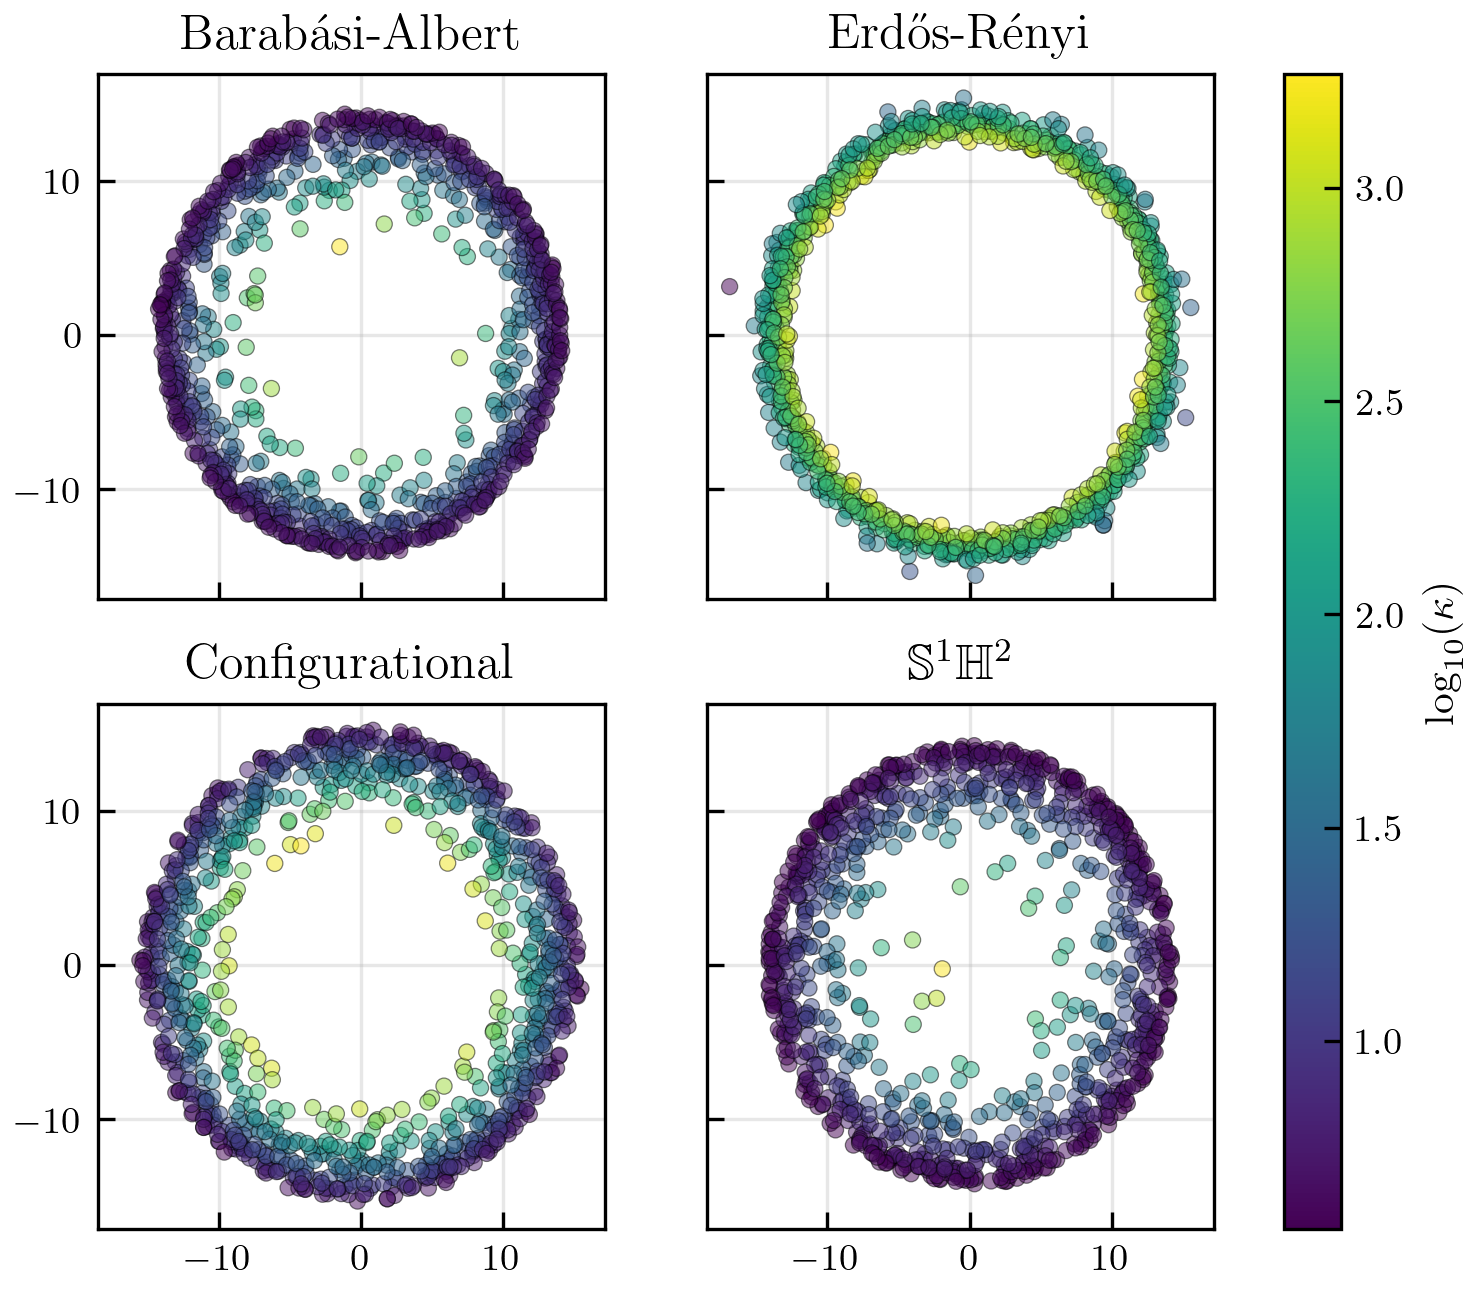

In [5]:
import pipeline.figures as figs
import matplotlib.pyplot as plt
import pipeline.init as init
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

init.configure_matplotlib()


fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 5), dpi=300)
[ax1, ax2, ax3, ax4] = axes.flat
arr = np.append(np.array([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa']]).flatten(), dfs1h2['Inf.Kappa'])
vmax = np.max(np.log10(arr))
vmin = np.min(np.log10(arr))

figs.mercator_disc_ax(ax1, dfba, title='Barabási-Albert')
figs.mercator_disc_ax(ax2, dfer,  title='Erdős-Rényi')
figs.mercator_disc_ax(ax3, dfconf,  title='Configurational')
figs.mercator_disc_ax(ax4, dfs1h2,  title=r'$\mathbb{S}^1\mathbb{H}^2$')

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

# Añadir la colorbar
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], label=r'$\log_{10}(\kappa)$')
# fig.suptitle('Synthetic complex networks - Mercator embedding\n$N=10^3, \\gamma=2.1, \\langle k \\rangle = 20, \\beta = 2.1$')
# fig.tight_layout()

fig.savefig('figs/mutliple_nets.pdf')
plt.show()

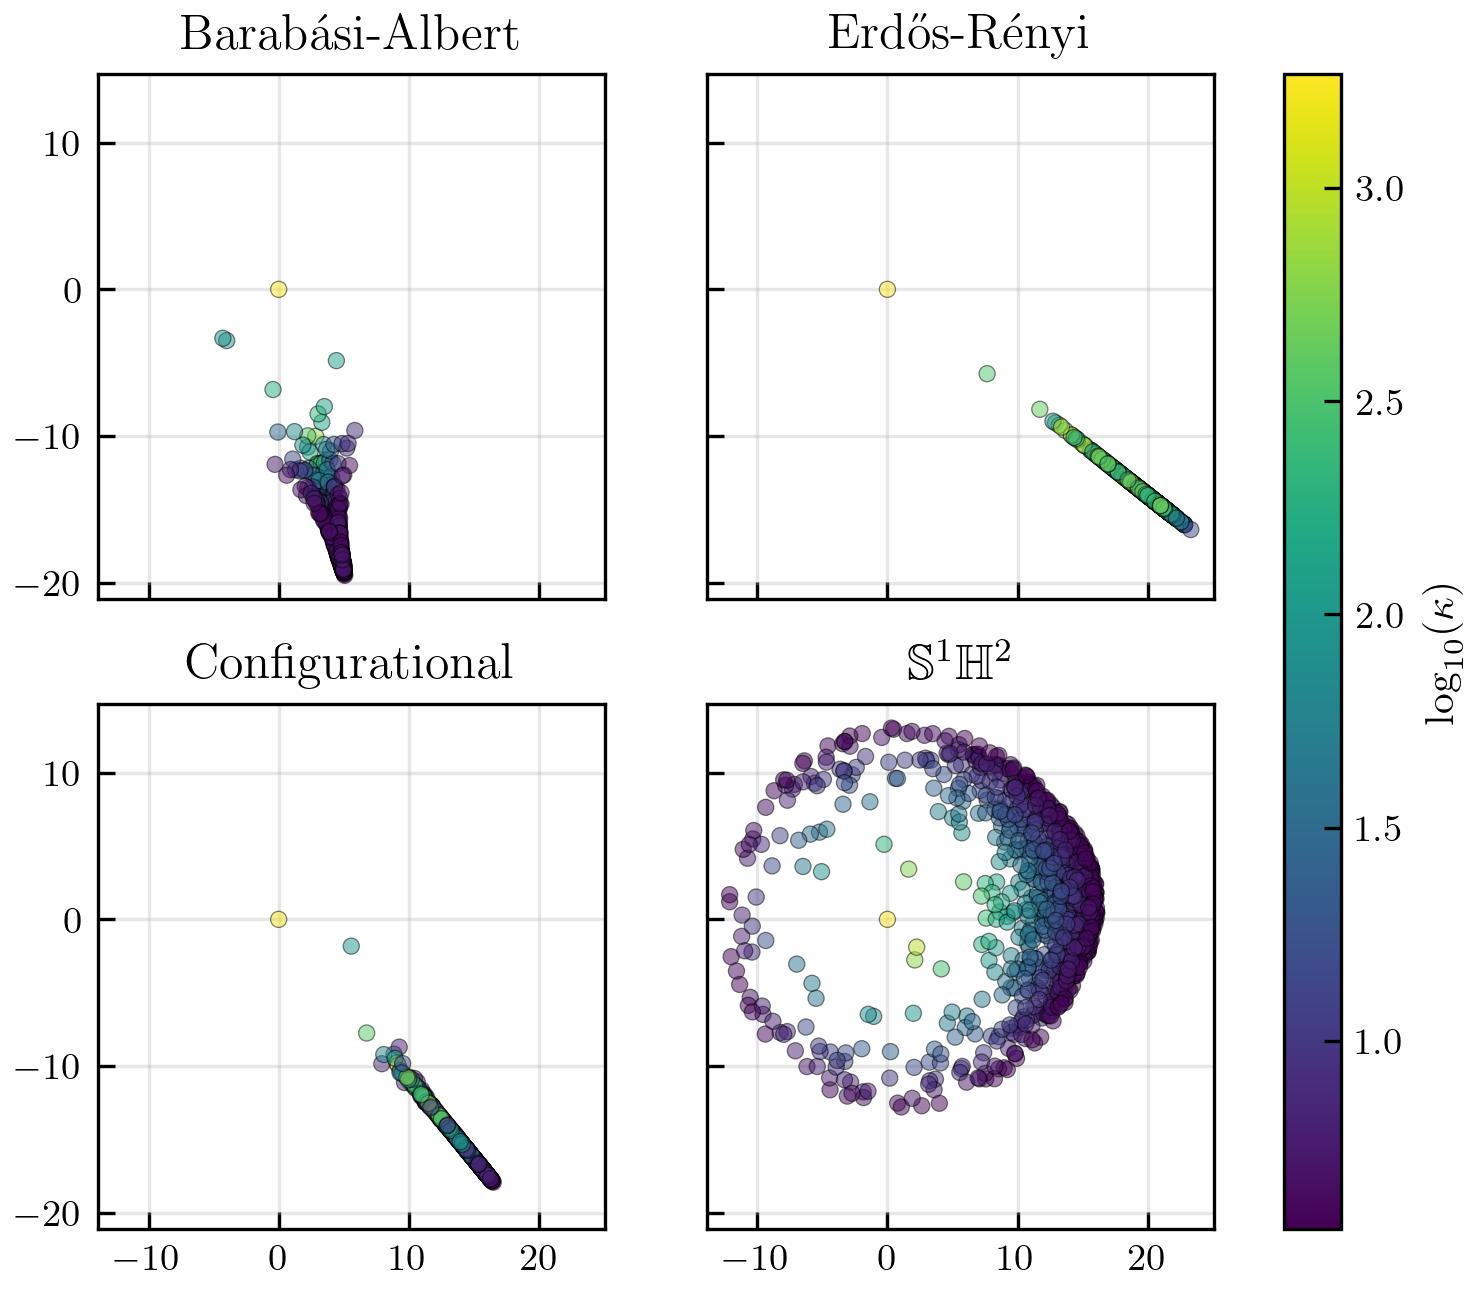

In [7]:
def center_df(df, start_node):
    import pandas as pd
    import pipeline.boost as boost
    
    selected = df[df['Vertex'] == start_node].iloc[0]
    r, theta = selected['Disc.Radius'], selected['Inf.Theta']

    r_changed, theta_changed = boost.centrar_en_origen(df['Disc.Radius'], df['Inf.Theta'], r, theta)
    df2 = pd.DataFrame()
    df2['Vertex'] = df['Vertex']
    df2['Inf.Kappa'] = df['Inf.Kappa']
    df2['Disc.Radius'] = r_changed
    df2['Inf.Theta'] = theta_changed
    df2['Disc.X'] = df2['Disc.Radius']*np.cos(df2['Inf.Theta'])
    df2['Disc.Y'] = df2['Disc.Radius']*np.sin(df2['Inf.Theta'])
    return df2


import pipeline.figures as figs
import matplotlib.pyplot as plt
import pipeline.init as init
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

init.configure_matplotlib()


fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 5), dpi=300)
[ax1, ax2, ax3, ax4] = axes.flat
arr = np.append(np.array([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa']]).flatten(), dfs1h2['Inf.Kappa'])
vmax = np.max(np.log10(arr))
vmin = np.min(np.log10(arr))


ba_popular = data.get_most_popular_node(Gba)
conf_popular = data.get_most_popular_node(Gconf)
s1h2_popular = data.get_most_popular_node(Gs1h2)
er_popular = data.get_most_popular_node(Ger)

figs.mercator_disc_ax(ax1, center_df(dfba,ba_popular), title='Barabási-Albert', linecolor='#00000015')
figs.mercator_disc_ax(ax2, center_df(dfer,er_popular),  title='Erdős-Rényi', linecolor='#00000015')
figs.mercator_disc_ax(ax3, center_df(dfconf,conf_popular),  title='Configurational', linecolor='#00000015')
figs.mercator_disc_ax(ax4, center_df(dfs1h2,s1h2_popular),  title=r'$\mathbb{S}^1\mathbb{H}^2$', linecolor='#00000015')

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

# Añadir la colorbar
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], label=r'$\log_{10}(\kappa)$')
# fig.suptitle('Synthetic complex networks - Mercator embedding\n$N=10^3, \\gamma=2.1, \\langle k \\rangle = 20, \\beta = 2.1$')
# fig.tight_layout()

fig.savefig('figs/mutliple_nets_boost.pdf')
plt.show()

Precalculando matriz para BA...


Procesando BA: 100%|██████████| 1000/1000 [00:00<00:00, 129401.91it/s]


Precalculando matriz para Configuracional...


Procesando Configuracional: 100%|██████████| 1000/1000 [00:00<00:00, 121341.90it/s]


Precalculando matriz para ER...


Procesando ER: 100%|██████████| 1000/1000 [00:00<00:00, 93836.50it/s]


Precalculando matriz para S1H2...


Procesando S1H2: 100%|██████████| 998/998 [00:00<00:00, 123635.15it/s]


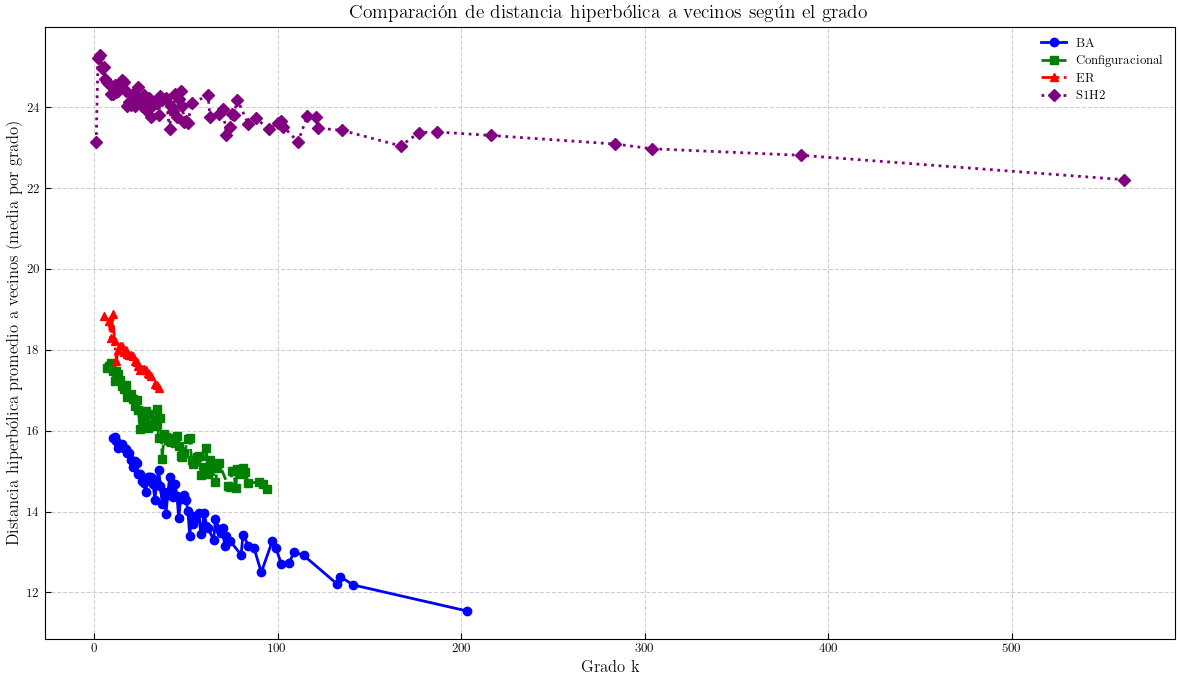

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def compute_average_l(df, G, nombre="Red"):
    """
    Calcula la distancia hiperbólica promedio a los vecinos para cada nodo
    y devuelve los grados únicos con su distancia media correspondiente.
    
    Retorna:
        unique_degrees : list, grados presentes en la red
        mean_dist_per_k : list, distancia media para cada grado
        nombre : str, identificador de la red
    """
    vertices = df['Vertex'].values
    vertex_to_idx = {v: i for i, v in enumerate(vertices)}
    radii = df['Disc.Radius'].values
    thetas = df['Inf.Theta'].values

    # Matriz de distancias hiperbólicas
    print(f"Precalculando matriz para {nombre}...")
    def hyperbolic_distance_matrix(r1, theta1, r2, theta2):
        cosh_r1 = np.cosh(r1)
        cosh_r2 = np.cosh(r2)
        sinh_r1 = np.sinh(r1)
        sinh_r2 = np.sinh(r2)
        delta_theta = np.abs(theta1[:, None] - theta2[None, :])
        cos_delta = np.cos(delta_theta)
        arg = cosh_r1[:, None] * cosh_r2[None, :] - sinh_r1[:, None] * sinh_r2[None, :] * cos_delta
        arg = np.clip(arg, 1.0, None)
        return np.arccosh(arg)
    D = hyperbolic_distance_matrix(radii, thetas, radii, thetas)

    # Verificar nodos sin coordenadas
    missing = set(G.nodes()) - set(vertex_to_idx.keys())
    if missing:
        print(f"Advertencia ({nombre}): {len(missing)} nodos sin coordenadas.")

    results = []  # (grado, avg_dist)
    for node in tqdm(G.nodes(), desc=f"Procesando {nombre}"):
        if node not in vertex_to_idx:
            continue
        idx = vertex_to_idx[node]
        neighbor_indices = [vertex_to_idx[nb] for nb in G.neighbors(node) if nb in vertex_to_idx]
        if not neighbor_indices:
            continue
        distances = D[idx, neighbor_indices]
        avg_dist = np.mean(distances)
        degree = G.degree(node)
        results.append((degree, avg_dist))

    if not results:
        print(f"{nombre}: no hay datos válidos.")
        return [], [], nombre

    # Agrupar por grado y calcular media
    results.sort(key=lambda x: x[0])
    unique_degrees = sorted(set(d for d, _ in results))
    mean_dist_per_k = []
    for k in unique_degrees:
        dists_k = [d for deg, d in results if deg == k]
        mean_dist_per_k.append(np.mean(dists_k))
    
    return unique_degrees, mean_dist_per_k, nombre

# ------------------------------------------------------------
# Calcular para las 4 redes
# ------------------------------------------------------------
data_ba = compute_average_l(dfba, Gba, nombre="BA")
data_conf = compute_average_l(dfconf, Gconf, nombre="Configuracional")
data_er = compute_average_l(dfer, Ger, nombre="ER")
data_s1h2 = compute_average_l(dfs1h2, Gs1h2, nombre="S1H2")

# ------------------------------------------------------------
# Gráfico combinado
# ------------------------------------------------------------
plt.figure(figsize=(12, 7))

# Definir estilos para cada red (color, marcador, línea)
estilos = {
    "BA": {'color': 'blue', 'marker': 'o', 'linestyle': '-'},
    "Configuracional": {'color': 'green', 'marker': 's', 'linestyle': '--'},
    "ER": {'color': 'red', 'marker': '^', 'linestyle': '-.'},
    "S1H2": {'color': 'purple', 'marker': 'D', 'linestyle': ':'}
}

for degrees, means, nombre in [data_ba, data_conf, data_er, data_s1h2]:
    if not degrees:
        continue
    estilo = estilos.get(nombre, {})
    plt.plot(degrees, means, 
             label=nombre, 
             color=estilo.get('color', 'black'),
             marker=estilo.get('marker', ''),
             linestyle=estilo.get('linestyle', '-'),
             linewidth=2,
             markersize=6)

plt.xlabel("Grado k", fontsize=12)
plt.ylabel("Distancia hiperbólica promedio a vecinos (media por grado)", fontsize=12)
plt.title("Comparación de distancia hiperbólica a vecinos según el grado", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

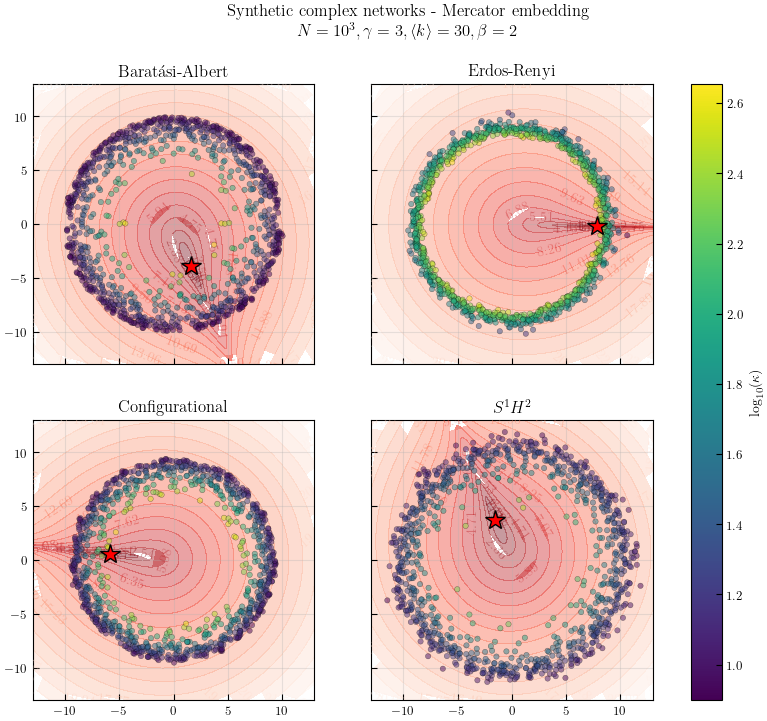

In [ ]:
import pipeline.figures as figs
import matplotlib.pyplot as plt
import pipeline.init as init
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

init.configure_matplotlib()


fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8), dpi=100)
ax1, ax2, ax3, ax4 = axes.flat
for ax in axes.flat:
    ax.set_xlim(-13, 13)
    ax.set_ylim(-13, 13)

vmax = np.max(np.log10([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa'], dfs1h2['Inf.Kappa']]))
vmin = np.min(np.log10([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa'], dfs1h2['Inf.Kappa']]))


figs.mercator_disc_ax(ax1, dfba, title='Baratási-Albert', mark_nodes=[ba_popular], isolines_nodes=[ba_popular])
figs.mercator_disc_ax(ax2, dfer, title='Erdos-Renyi', mark_nodes=[er_popular], isolines_nodes=[er_popular])
figs.mercator_disc_ax(ax3, dfconf, title='Configurational', mark_nodes=[conf_popular], isolines_nodes=[conf_popular])
figs.mercator_disc_ax(ax4, dfs1h2, title=r'$S^1H^2$', mark_nodes=[s1h2_popular], isolines_nodes=[s1h2_popular])

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

# Añadir la colorbar
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], label=r'$\log_{10}(\kappa)$')
fig.suptitle('Synthetic complex networks - Mercator embedding\n$N=10^3, \\gamma=3, \\langle k \\rangle = 30, \\beta = 2$')
# fig.tight_layout()
plt.show()

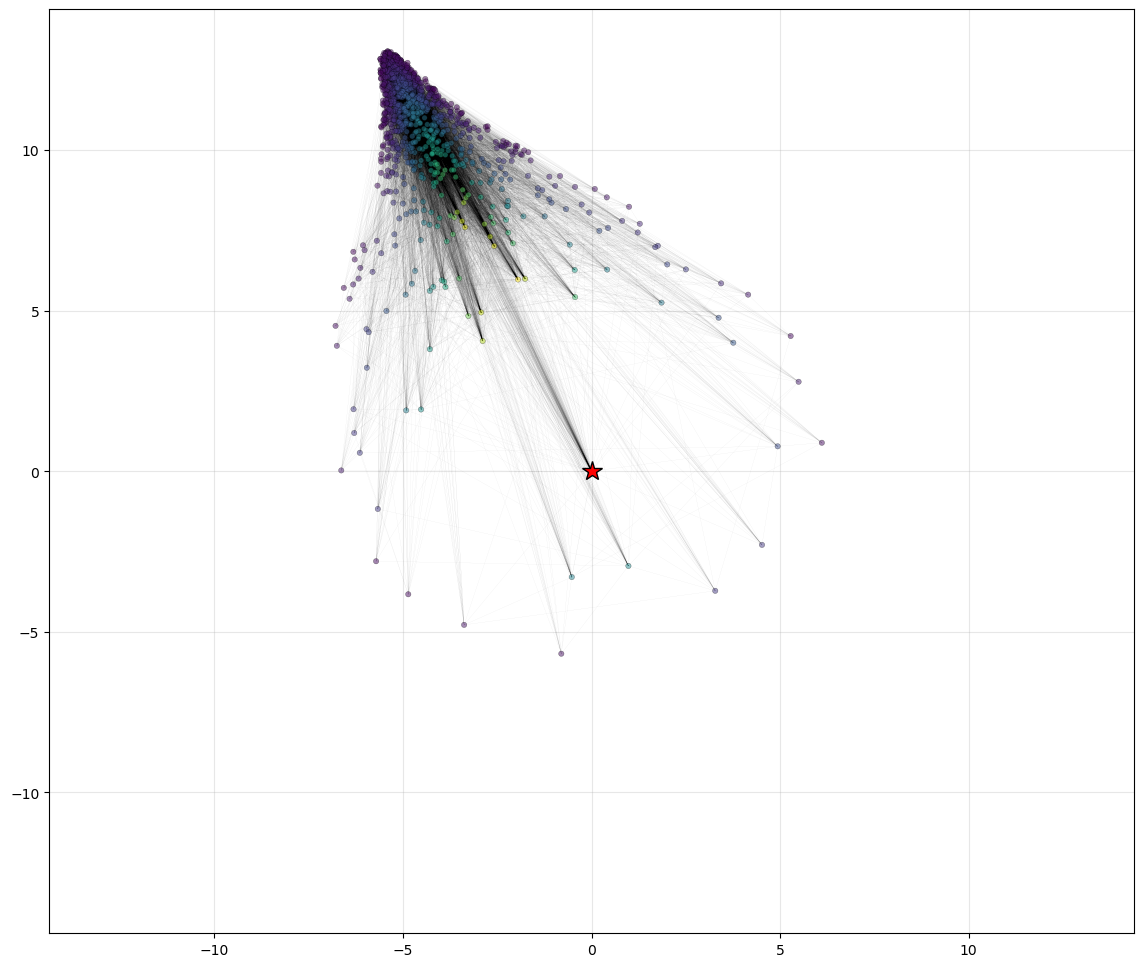

In [ ]:
import pipeline.figures as figs
import numpy as np
df = dfba
G = Gba
start_node = data.get_most_popular_node(G)


df2 = center_df(df, start_node)


figs.mercator_disc(df, [start_node], net=G)

# Epidèmia

In [21]:
output_batch_file_random = f"{working_folder}/batch_sir_evolution_random.txt"

infection_rates = [100]      # 1..100
random_seeds = range(1, 31)       # 1..60

recovery_rate = 1E-1
limit_time = 1E10
model_type = 2   # SIR_MODEL
n = 0

with open(output_batch_file_random, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type start_node\n")
    for i in infection_rates:
        infection_rate = i / 100.0   # real(i_sim*2, dp)/100
        for j in random_seeds:
            seed = 42069 + j
            # Escribir línea con 5 valores (start_node opcional omitido)
            for k in range(1000):
                f.write(f"{infection_rate:.6f} {recovery_rate:.6f} {seed} {limit_time:.1f} {model_type} {k}\n")
                n = n+1

print(f"Archivo batch generado: {output_batch_file_random} con {n} simulaciones.")

Archivo batch generado: ./generated-nets/batch_sir_evolution_random.txt con 30000 simulaciones.


In [ ]:
import pandas as pd
import pipeline.hyperbolic as hyp
sets = [
    (Gba, dfba, paramsba, ba_edges_file),
    (Ger, dfer, paramser, er_edges_file),
    (Gconf, dfconf, paramsconf, conf_edges_file),
    (Gs1h2 , dfs1h2, paramss1h2, s1h2_edges_file)
]

for (G, df, params, edges_file) in sets:
    R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))


    edges = pd.DataFrame(G.edges, columns=['a', 'b'])
    edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='a', right_on='Vertex', suffixes=('_a', '_b'))
    edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='b', right_on='Vertex', suffixes=('_a', '_b'))
    edges['Theta_Dif'] = np.pi - np.abs(np.pi - np.abs(edges['Inf.Theta_a']-edges['Inf.Theta_b']))

    edges['Distance'] = np.where(edges['Theta_Dif'] == 0, 
                                np.abs(edges['Disc.Radius_a']- edges['Disc.Radius_b']), 
                                hyp.hyperbolic_distance_og(edges['Disc.Radius_a'], edges['Disc.Radius_b'], edges['Theta_Dif']))



    for n in range(10):
        c = -(n+1)/10
        edges['Epidemic_Func'] = hyp.link_probability_og(edges['Distance'], R, c)

        avg_epidemic_func = np.average(edges['Epidemic_Func'])

        edges['Weight_Multiplier'] = edges['Epidemic_Func']/avg_epidemic_func
        edges.to_csv(f"{edges_file}_weight_-{n+1}x10^-1", sep='\t', header=False, index=False, columns=['a', 'b', 'Weight_Multiplier'])

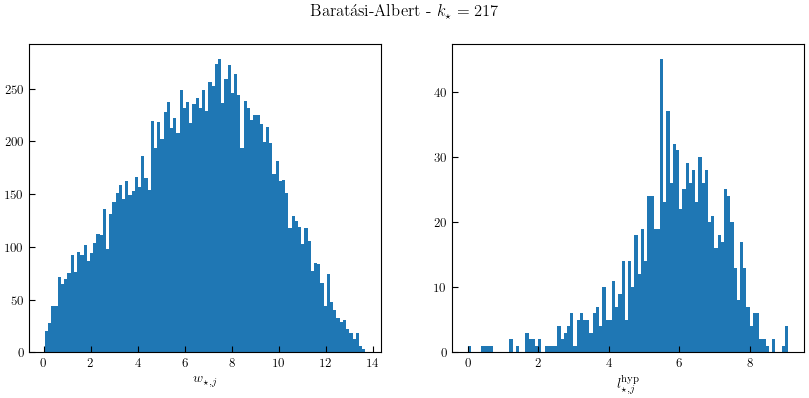

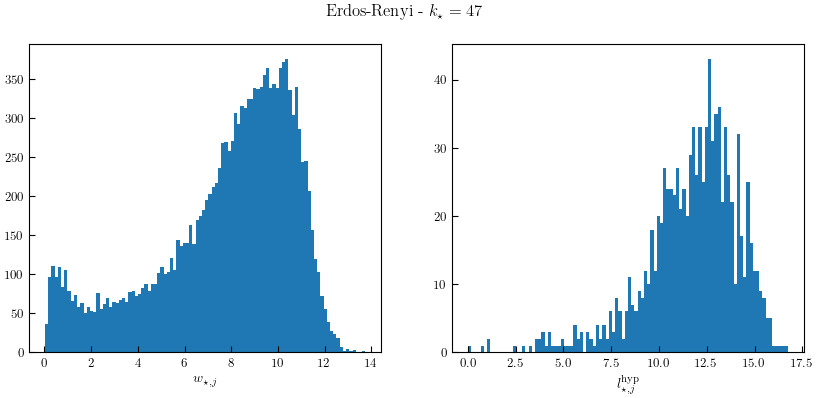

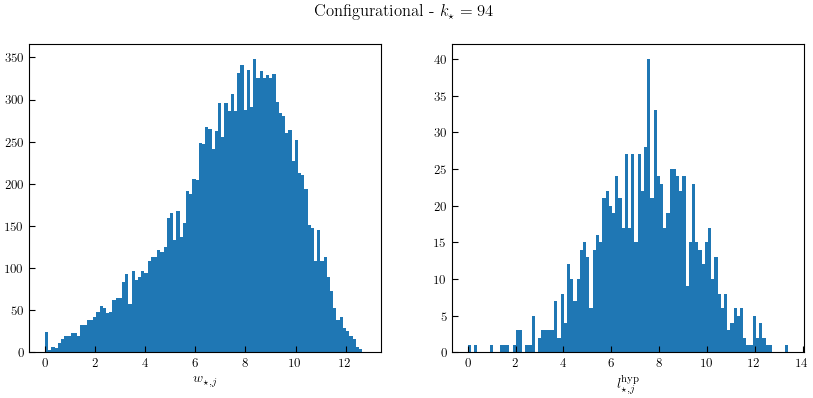

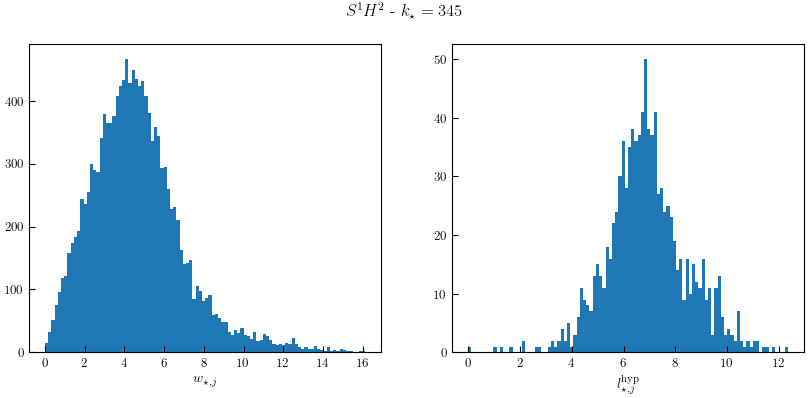

In [30]:
import networkx as nx
sets = [
    (Gba, dfba, 'Baratási-Albert'),
    (Ger, dfer, 'Erdos-Renyi'),
    (Gconf, dfconf, 'Configurational'),
    (Gs1h2 , dfs1h2, r'$S^1H^2$')
]

for (G, df, title) in sets:
    coords = (
        df.set_index('Vertex')
        [['Disc.Radius', 'Inf.Theta']]
        .to_dict('index')
    )

    for u, v in G.edges():
        
        r1 = coords[u]['Disc.Radius']
        t1 = coords[u]['Inf.Theta']

        r2 = coords[v]['Disc.Radius']
        t2 = coords[v]['Inf.Theta']

        d = hyp.hyperbolic_distance_og_thetas(r1, t1, r2, t2)

        G[u][v]['weight'] = d
    start_node = data.get_most_popular_node(G)
    weights = [
        G[u][v]['weight']
        for u,v in G.edges()
    ]

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4)) 

    ax1.hist(weights, bins=100)
    ax1.set_xlabel(r'$w_{\star,j}$')

    hyp_distance = nx.single_source_dijkstra_path_length(
        G,
        start_node,
        weight='weight'
    )

    hops_dist = nx.single_source_dijkstra_path_length(
        G,
        start_node,
        weight=None
    )
    
    ax2.hist(hyp_distance.values(), bins=100)
    ax2.set_xlabel(r'$l^\text{hyp}_{\star,j}$')
    deg = G.degree()[start_node]
    # ax3.hist(hops_dist.values(), bins=10)
    # ax3.set_xlabel(r'$l_\text{top}$')
    fig.suptitle(title + rf' - $k_\star = {deg}$')
    plt.show()